In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [3]:
#Loading the dataset
diabetes_data = pd.read_csv('diabetes.csv')

#Print the first 5 rows of the dataframe.
diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
## observing the shape of the data
diabetes_data.shape

(768, 9)

In [5]:
X = diabetes_data.drop("Outcome",axis = 1)
y = diabetes_data.Outcome

In [6]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [7]:
#importing train_test_split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=1/3,random_state=42, stratify=y)

# Decision Tree

In [8]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion='entropy',random_state=0)
dt.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(dt.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(dt.score(X_test, y_test)))

Accuracy on training set: 1.000
Accuracy on test set: 0.703


The accuracy on the training set is 100%, while the test set accuracy is much worse. This is an indicative that the tree is overfitting and not generalizing well to new data. Therefore, we need to apply pre-pruning to the tree.

We set max_depth=3, limiting the depth of the tree decreases overfitting. This leads to a lower accuracy on the training set, but an improvement on the test set.

In [9]:
dt = DecisionTreeClassifier(criterion='entropy',max_depth=3, random_state=0)
dt.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(dt.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(dt.score(X_test, y_test)))

Accuracy on training set: 0.793
Accuracy on test set: 0.730


In [10]:
y_pred = dt.predict(X_test)


In [11]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[145  22]
 [ 47  42]]
              precision    recall  f1-score   support

           0       0.76      0.87      0.81       167
           1       0.66      0.47      0.55        89

    accuracy                           0.73       256
   macro avg       0.71      0.67      0.68       256
weighted avg       0.72      0.73      0.72       256



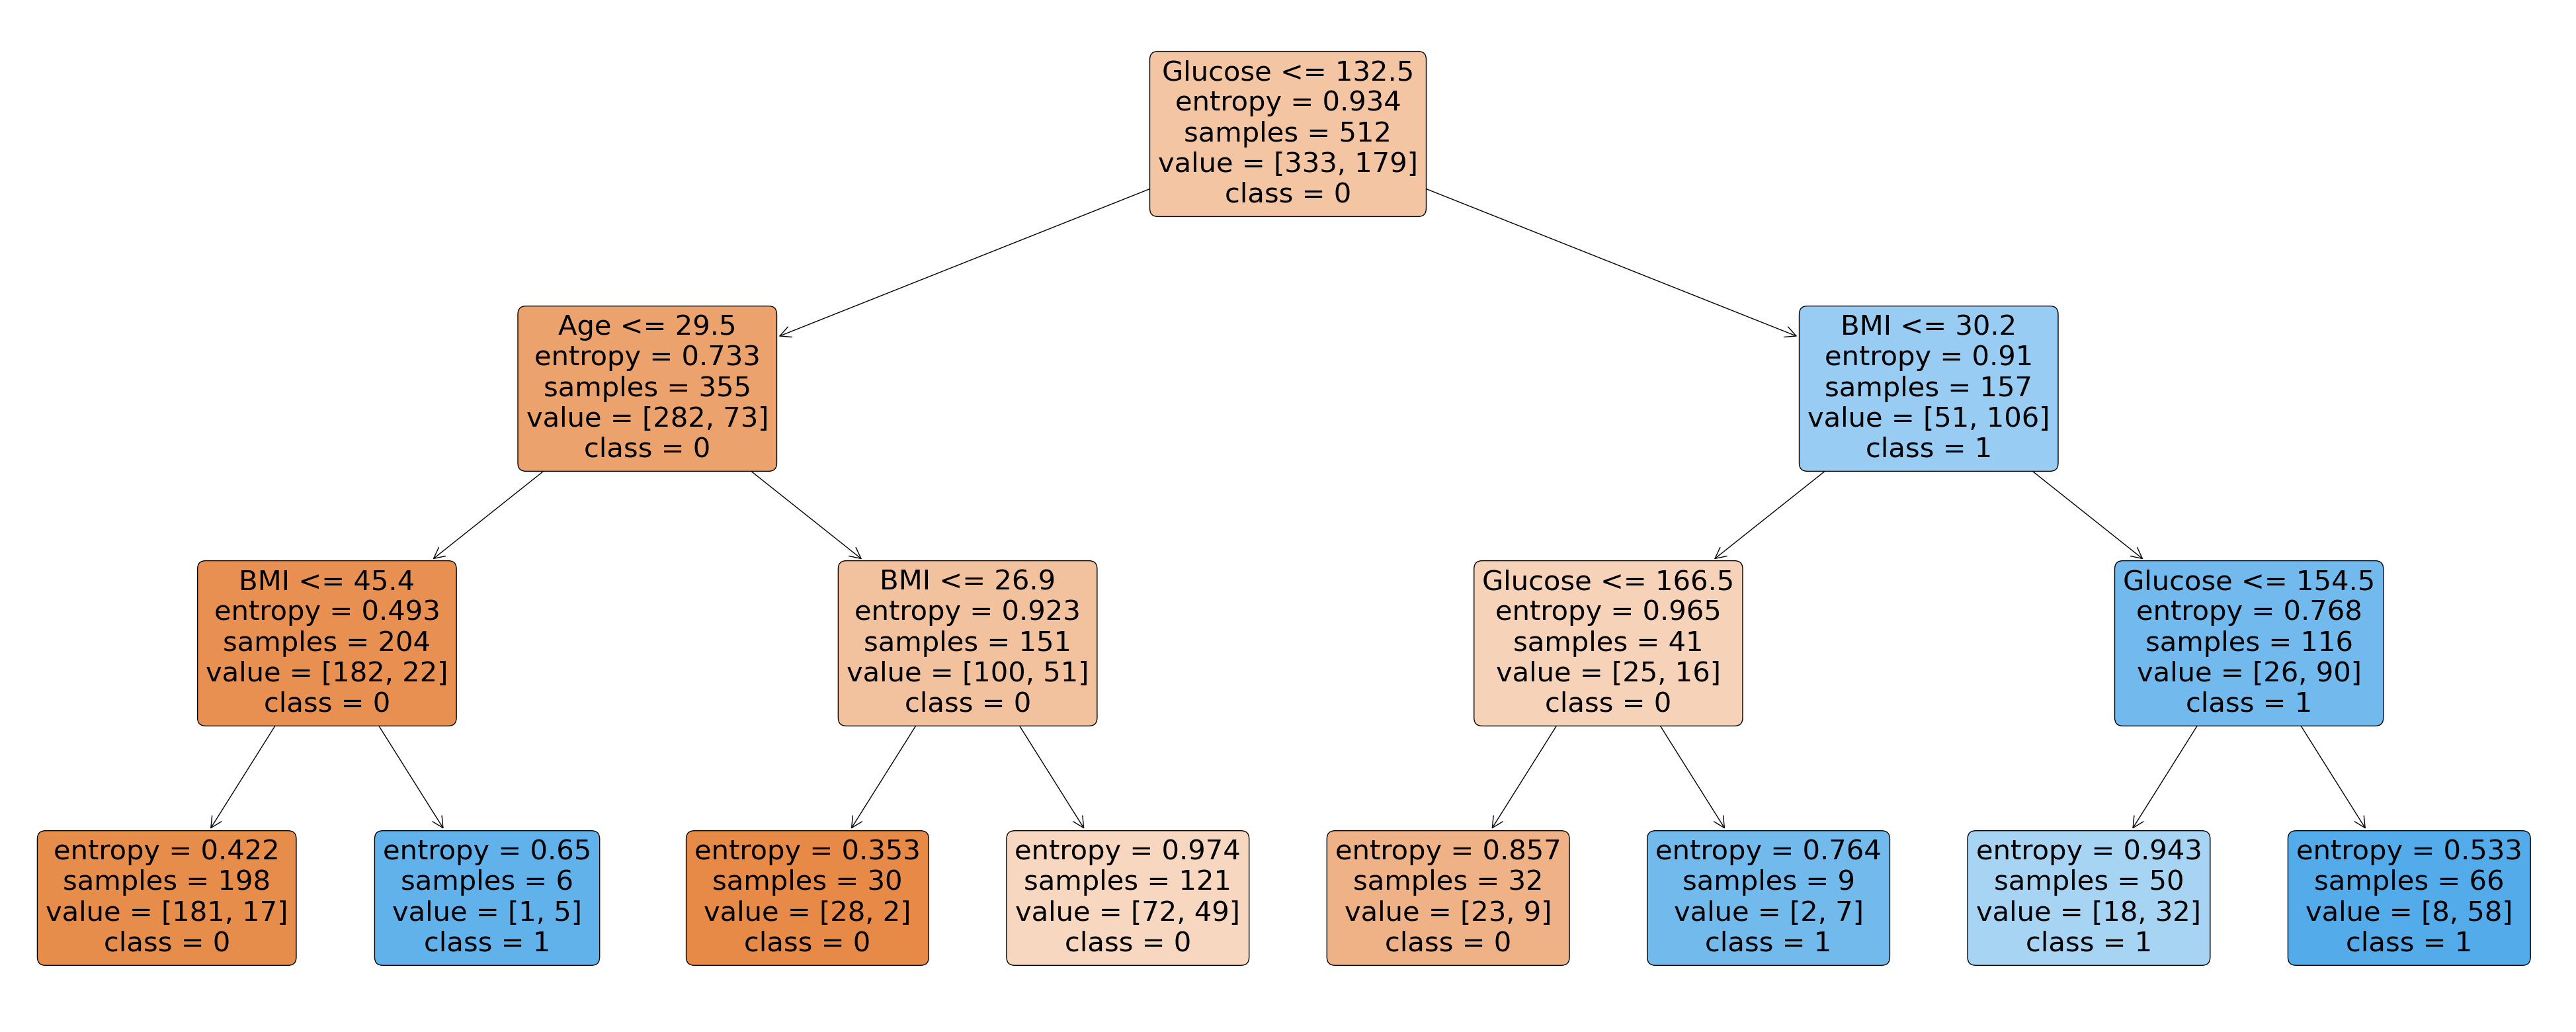

In [13]:
from sklearn import tree
import pydotplus
#import matplotlib.pyplot as plt
plt.figure(figsize=[50,20])

feature_names=X.columns.tolist()
tree.plot_tree(dt,filled=True,fontsize=30,rounded=True,feature_names=feature_names,class_names=['0','1'])
plt.show()

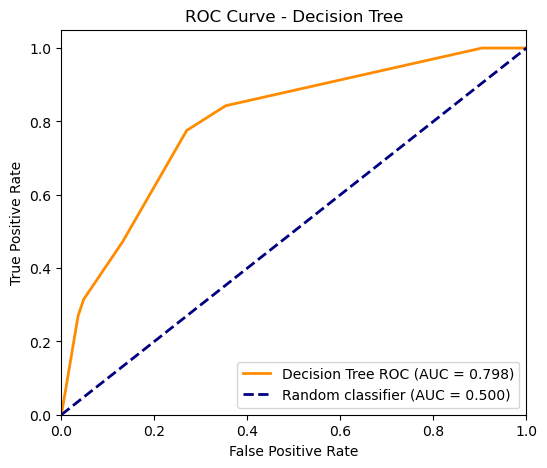

In [14]:
from sklearn.metrics import roc_curve, auc

y_pred_proba = dt.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2,
         label=f"Decision Tree ROC (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--",
         label="Random classifier (AUC = 0.500)")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend(loc="lower right")
plt.show()

In [15]:
# Adjust the decision tree parameters to improve the performance.
results = []
criterion_values = ["gini", "entropy"]
max_depth_values = [2, 3, 4, 5, 6, 7, 8, 10, None]
min_samples_leaf_values = [1, 2, 5, 10]

for criterion in criterion_values:
    for max_depth in max_depth_values:
        for min_samples_leaf in min_samples_leaf_values:
            model = DecisionTreeClassifier(
                criterion=criterion,
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                random_state=0
            )
            model.fit(X_train, y_train)
            train_acc = model.score(X_train, y_train)
            test_acc = model.score(X_test, y_test)
            results.append((test_acc, train_acc, criterion, max_depth, min_samples_leaf))

results.sort(key=lambda x: x[0], reverse=True)

print("Top 5 DT models by test accuracy:")
for test_acc, train_acc, criterion, max_depth, min_samples_leaf in results[:5]:
    print(f"criterion={criterion}, max_depth={max_depth}, min_samples_leaf={min_samples_leaf} "
          f"-> train={train_acc:.3f}, test={test_acc:.3f}")

best_test_acc, best_train_acc, best_criterion, best_max_depth, best_min_samples_leaf = results[0]
best_dt = DecisionTreeClassifier(
    criterion=best_criterion,
    max_depth=best_max_depth,
    min_samples_leaf=best_min_samples_leaf,
    random_state=0
)
best_dt.fit(X_train, y_train)
dt = best_dt

print("\nBest DT model:")
print(classification_report(y_test, dt.predict(X_test)))
print(confusion_matrix(y_test, dt.predict(X_test)))

Top 5 DT models by test accuracy:
criterion=entropy, max_depth=6, min_samples_leaf=5 -> train=0.850, test=0.773
criterion=entropy, max_depth=7, min_samples_leaf=5 -> train=0.855, test=0.773
criterion=gini, max_depth=6, min_samples_leaf=10 -> train=0.822, test=0.770
criterion=gini, max_depth=7, min_samples_leaf=10 -> train=0.828, test=0.770
criterion=gini, max_depth=8, min_samples_leaf=10 -> train=0.828, test=0.770

Best DT model:
              precision    recall  f1-score   support

           0       0.80      0.87      0.83       167
           1       0.71      0.60      0.65        89

    accuracy                           0.77       256
   macro avg       0.75      0.73      0.74       256
weighted avg       0.77      0.77      0.77       256

[[145  22]
 [ 36  53]]


Decision Tree feature importance:
Glucose                     0.387807
BMI                         0.262265
DiabetesPedigreeFunction    0.116902
Age                         0.115278
Pregnancies                 0.067228
Insulin                     0.019367
BloodPressure               0.016777
SkinThickness               0.014375
dtype: float64


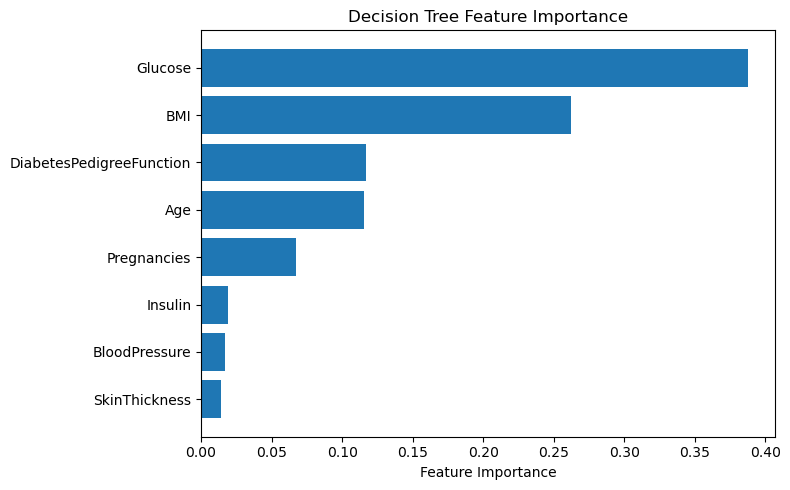

In [17]:
# Find the feature importance from the decision tree built above.
feature_importance = pd.Series(
    dt.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Decision Tree feature importance:")
print(feature_importance)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance.index[::-1], feature_importance.values[::-1])
plt.xlabel("Feature Importance")
plt.title("Decision Tree Feature Importance")
plt.tight_layout()
plt.show()


# NN

In [18]:

scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(10,10), max_iter=1000,verbose=2)
mlp.fit(X_train, y_train)

Iteration 1, loss = 0.88643109
Iteration 2, loss = 0.87305712
Iteration 3, loss = 0.86020910
Iteration 4, loss = 0.84784381
Iteration 5, loss = 0.83524110
Iteration 6, loss = 0.82404927
Iteration 7, loss = 0.81259652
Iteration 8, loss = 0.80228634
Iteration 9, loss = 0.79153586
Iteration 10, loss = 0.78154706
Iteration 11, loss = 0.77164922
Iteration 12, loss = 0.76206347
Iteration 13, loss = 0.75341564
Iteration 14, loss = 0.74450534
Iteration 15, loss = 0.73611704
Iteration 16, loss = 0.72804863
Iteration 17, loss = 0.71984494
Iteration 18, loss = 0.71226946
Iteration 19, loss = 0.70557450
Iteration 20, loss = 0.69833415
Iteration 21, loss = 0.69125195
Iteration 22, loss = 0.68506623
Iteration 23, loss = 0.67861322
Iteration 24, loss = 0.67276463
Iteration 25, loss = 0.66669121
Iteration 26, loss = 0.66117394
Iteration 27, loss = 0.65561135
Iteration 28, loss = 0.65036577
Iteration 29, loss = 0.64538534
Iteration 30, loss = 0.64038424
Iteration 31, loss = 0.63576122
Iteration 32, los

MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=1000, verbose=2)

In [20]:
predictions = mlp.predict(X_test)


print("Accuracy", metrics.accuracy_score(y_test, predictions))
print(confusion_matrix(y_test,predictions))
print(classification_report(y_test,predictions))

Accuracy 0.7578125
[[142  25]
 [ 37  52]]
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       167
           1       0.68      0.58      0.63        89

    accuracy                           0.76       256
   macro avg       0.73      0.72      0.72       256
weighted avg       0.75      0.76      0.75       256



In [21]:
print("Accuracy on training set: {:.3f}".format(mlp.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(mlp.score(X_test, y_test)))

Accuracy on training set: 0.873
Accuracy on test set: 0.758


In [22]:
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib
import pandas as pd
import numpy as np

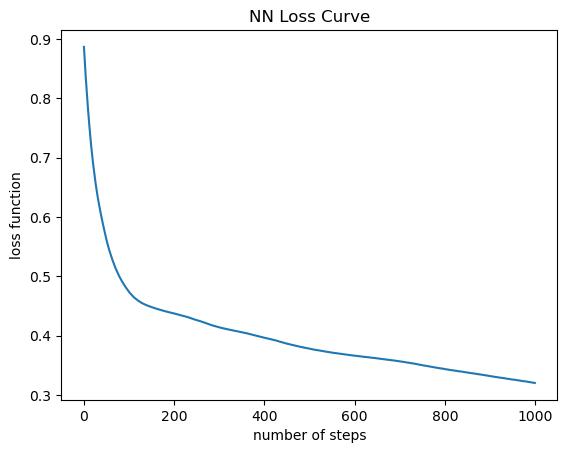

In [23]:
plt.plot(mlp.loss_curve_)
plt.title("NN Loss Curve")
plt.xlabel("number of steps")
plt.ylabel("loss function")
plt.show()

In [ ]:
#check out weights

In [24]:
(mlp.intercepts_[0]).shape

(10,)

In [25]:
(mlp.coefs_[0]).shape

(8, 10)

In [26]:
mlp.intercepts_[0]

array([-0.16137933, -0.23140464,  0.23799559,  0.97983738, -0.05920854,
       -0.25052251,  0.42507617, -0.24801915,  0.67317387,  0.34986232])

In [27]:
mlp.coefs_[0]

array([[ 0.90759888, -0.87638744,  0.9634794 ,  0.49465643,  0.22420102,
        -0.59155755, -0.71321687,  0.14090369, -0.30097821,  0.15285377],
       [ 0.79273582, -0.23705912, -0.1155153 , -0.19932905, -0.77434839,
         0.38110875,  0.61526052, -0.63055004,  0.19220717, -0.07762401],
       [-0.74958719,  0.49885394,  0.26886198,  0.18448463,  0.07918648,
        -0.12021481,  0.55833399, -1.17308526,  0.28021552, -0.42895568],
       [ 0.31688776,  0.48014115, -0.06488941,  0.43427829, -0.38341574,
        -0.61989815,  0.70171471,  0.20856156,  0.14773894, -0.10800086],
       [-0.0705303 , -0.96739944, -0.49143551, -0.04378525,  0.52889021,
         0.51322335, -0.27454085,  0.28235496,  0.48793289, -0.2293945 ],
       [ 0.19615003, -0.47023053, -0.44994125,  0.00995229, -0.02036037,
        -0.24955796,  0.45223434, -1.23226662, -0.13768766, -0.22304262],
       [-0.08541686,  0.07053722,  0.18251471, -0.32905835,  0.0855683 ,
        -0.82673178,  0.21334901,  0.10188876

In [28]:
# Adjust the number of hidden layers / hidden nodes to improve the NN performance.
candidate_hidden_layers = [
    (5,),
    (10,),
    (20,),
    (10, 10),
    (20, 20),
    (10, 10, 10),
]

nn_results = []
for hidden_layers in candidate_hidden_layers:
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        max_iter=1000,
        random_state=0
    )
    model.fit(X_train, y_train)
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    nn_results.append((test_acc, train_acc, hidden_layers))

nn_results.sort(key=lambda x: x[0], reverse=True)

print("NN performance for different hidden-layer structures:")
for test_acc, train_acc, hidden_layers in nn_results:
    print(f"hidden_layer_sizes={hidden_layers}: train={train_acc:.3f}, test={test_acc:.3f}")

best_test_acc, best_train_acc, best_hidden_layers = nn_results[0]
best_mlp = MLPClassifier(
    hidden_layer_sizes=best_hidden_layers,
    max_iter=1000,
    random_state=0
)
best_mlp.fit(X_train, y_train)
mlp = best_mlp

print("\nBest NN structure:", best_hidden_layers)
print(classification_report(y_test, mlp.predict(X_test)))
print(confusion_matrix(y_test, mlp.predict(X_test)))


NN performance for different hidden-layer structures:
hidden_layer_sizes=(10,): train=0.811, test=0.742
hidden_layer_sizes=(5,): train=0.795, test=0.734
hidden_layer_sizes=(20,): train=0.850, test=0.730
hidden_layer_sizes=(10, 10): train=0.869, test=0.711
hidden_layer_sizes=(10, 10, 10): train=0.953, test=0.707
hidden_layer_sizes=(20, 20): train=0.969, test=0.703

Best NN structure: (10,)
              precision    recall  f1-score   support

           0       0.78      0.85      0.81       167
           1       0.66      0.54      0.59        89

    accuracy                           0.74       256
   macro avg       0.72      0.69      0.70       256
weighted avg       0.73      0.74      0.74       256

[[142  25]
 [ 41  48]]


# SVM


In [29]:
from sklearn.svm import SVC

gamma1, gamma2 = 0.1, 1
C1, C2 = 1, 10
hyperparams = (gamma1, C1), (gamma1, C2), (gamma2, C1), (gamma2, C2)

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

svm_clfs = []
for gamma, C in hyperparams:
    svm_clf=SVC(kernel="rbf",gamma=gamma, C=C)
    svm_clf.fit(X_train,y_train)
    svm_clfs.append(svm_clf)

from sklearn.metrics import classification_report, confusion_matrix
for i, svm_clf in enumerate(svm_clfs):
    predictions = svm_clf.predict(X_test)
    gamma, C = hyperparams[i]
    print("r=", gamma, "C=", C)
    print("Accuracy=", metrics.accuracy_score(y_test, predictions))
    print(confusion_matrix(y_test,predictions))
    print(classification_report(y_test,predictions))


r= 0.1 C= 1
Accuracy= 0.75390625
[[143  24]
 [ 39  50]]
              precision    recall  f1-score   support

           0       0.79      0.86      0.82       167
           1       0.68      0.56      0.61        89

    accuracy                           0.75       256
   macro avg       0.73      0.71      0.72       256
weighted avg       0.75      0.75      0.75       256

r= 0.1 C= 10
Accuracy= 0.7109375
[[134  33]
 [ 41  48]]
              precision    recall  f1-score   support

           0       0.77      0.80      0.78       167
           1       0.59      0.54      0.56        89

    accuracy                           0.71       256
   macro avg       0.68      0.67      0.67       256
weighted avg       0.71      0.71      0.71       256

r= 1 C= 1
Accuracy= 0.70703125
[[150  17]
 [ 58  31]]
              precision    recall  f1-score   support

           0       0.72      0.90      0.80       167
           1       0.65      0.35      0.45        89

    accuracy    

# deployment

In [30]:
import pickle
# save the model to disk
filename = 'finalized_model.sav'
pickle.dump(mlp, open(filename, 'wb'))

# some time later...

# load the model from disk
loaded_model = pickle.load(open(filename, 'rb'))
#result = loaded_model.score(X_test, y_test)
#print(result)

pred = loaded_model.predict(X_test)
print(pred)


[0 0 1 0 1 1 1 1 0 0 1 0 1 1 1 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 1 0 1 1 1 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 1
 0 1 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 1 0 0 0 1 0 1 0 1 1 1 0 0 0 0 0 1
 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 1 0 1 0 0 1 0 1 1 0 0 1 0 1 0 1 0 1 0 0
 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 1 1
 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 0 1 1 1 0 0 1
 0 0 1 1 1 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0]


# Model Comparison

## Performance comparison (test accuracy)
| Model | Best setting | Test accuracy | Class 1 recall |
|---|---:|---:|---:|
| Decision Tree | `entropy, max_depth=6, min_samples_leaf=5` | 0.773 | 0.60 |
| SVM | `rbf, gamma=0.1, C=1` | 0.754 | 0.56 |
| Neural Network | `hidden_layer_sizes=(10,), max_iter=1000` | 0.742 | 0.54 |

## Main observations
- On this data split, the tuned decision tree has the highest accuracy and the highest class-1 recall among the three models.
- The unpruned decision tree overfits strongly: training accuracy `1.000`, test accuracy `0.703`. Limiting tree depth improves generalization.
- Deeper/larger NN structures tend to overfit here; the single hidden layer with `10` nodes performed best.
- For SVM, larger `gamma` or `C` does not always improve test accuracy. `gamma=0.1, C=1` was best in this notebook.
- Class `0` is easier to predict for all three models; class `1` recall remains the main weakness.


# Additional code for your reference:
https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html